
# The Basics of MFML

This example demonstrates how to use the MFML-QC package to load the
built-in Benzene trajectory dataset, manually extract a multi-fidelity
subset using a top-down approach (that is start with the highest fidelity
then move down the fidelity hierarchy), and train an MFML model
to predict high-fidelity excitation energies.


In [1]:
# sphinx_gallery_thumbnail_path = '../../data/media/MFML_pyramid.png'

## Imports and Helper Functions
Before we begin the actual MFML workflow, let's define two highly reusable helper functions.
These are present in the utils script of the MFML package.

The first function parses our raw CSV arrays, mean-centers
the target properties,and establishes the foundational
``indexes`` mapping arrays that link high-fidelity calculations back to their
low-fidelity entries and corresponding geometries.

The second helper function handles **Top-Down Nested Extraction**.
Because the provided benzene datasets is sparsely populated at high fidelities,
a top-down extraction of the data guarantees that any geometry selected for a high-fidelity
training set is strictly included in all lower-fidelity training sets beneath it.
Note that in practice, however, one would start from the lowest fidelity and try to
build their way up from there (Such as Adaptive-MFMLO. This will form a separate tutorial.



In [2]:
import os
import numpy as np
from mfml_qc.datasets import load_benzene_data
from mfml_qc.mfml import ModelMFML
from mfml_qc.utils import build_hierarchy_arrays, top_down_subsetting

/home/vvinod/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading and Splitting the Dataset
Let's load the built-in Benzene dataset and split it chronologically into
a training pool (the first 12,288 geometries) and a test set.
We will use a 4-fidelity example which in increasing order of accuracy are
LC-DFTB, TD-DFT (STO-3G), TD-DFT (def2-SVP), and TD-DFT (def2-TZVP).



In [3]:
print("Loading Benzene dataset via built-in loader...")
dataset = load_benzene_data()

X_CM = dataset["X_CM"]
data = dataset["energies"]

# LC-DFTB (Col 2) -> STO-3G (Col 3) -> def2-SVP (Col 6) -> def2-TZVP (Col 7)
hierarchy_cols = [2, 3, 6, 7]
num_fids = len(hierarchy_cols)

train_mask = data[:, 0] < 12288
test_mask = data[:, 0] >= 12288

X_train_parent = X_CM[train_mask]
X_test = X_CM[test_mask]
data_train = data[train_mask]
data_test = data[test_mask]

print(data_train.shape, data_test.shape)

Loading Benzene dataset via built-in loader...
(12288, 9) (2712, 9)


## Preparing the Multi-Fidelity Data
We use our helper functions to extract the full valid arrays, and then apply
the top-down nested extraction to enforce our specific target sizes.
Here we will use 1024 samples at LC-DFTB, 512 at STO-3G, 256 at def2-SVP, and 128 samples at def2-TZVP



In [4]:
y_trains, indexes, means = build_hierarchy_arrays(data_train, hierarchy_cols)
n_trains_target = [1024, 512, 256, 128]
subset_y_trains, subset_indexes = top_down_subsetting(
    y_trains, indexes, n_trains_target, seed=42
)

## Instantiating the MFML Model
With our data strictly nested and formatted, we can instantiate the
``ModelMFML`` class. It will automatically build and train the
2N - 1 underlying sub-models required.



In [5]:
mfml_model = ModelMFML(kernel="matern", sigma=715.0, reg=1e-9, p_bar=False)

We pass the subset arrays here to train on our specific N_trains targets.
In a different example where we carry out a bottom-to-top data nestedness,
we will come across an internal shuffler built in for the MFML.
It must be noted that shuffling of training data here is what is
often called random sub-sampling. The order of the data itself in training
kernel based models does not affect the model.



In [6]:
mfml_model.train(
    X_train_parent=X_train_parent, y_trains=subset_y_trains, indexes=subset_indexes
)

Extracting X_trains:   0%|                                                                                                         | 0/4 [00:00<?, ?it/s]

Extracting upper y_trains:   0%|                                                                                                   | 0/4 [00:00<?, ?it/s]

Extracting lower y_trains:   0%|                                                                                                   | 0/3 [00:00<?, ?it/s]

Training upper ML models...:   0%|                                                                                                 | 0/4 [00:00<?, ?it/s]

Training upper ML models...:  25%|██████████████████████▎                                                                  | 1/4 [00:02<00:07,  2.38s/it]

Training lower ML models:   0%|                                                                                                    | 0/3 [00:00<?, ?it/s]

## Predicting and Evaluating
We predict the test geometries using the standard +1 and -1
wieghts and un-center the predictions using the highest-fidelity mean.



In [7]:
# Pick def2-TZVP (highest fidelity) as our "ground truth" test targets
y_test_true = data_test[:, hierarchy_cols[-1]]
preds = mfml_model.predict(X_test=X_test, optimiser="default")
preds += means[-1]

# Calculate Mean Absolute Error
mae = np.mean(np.abs(preds - y_test_true))
mae_kcal = mae * 23  # Conversion factor: eV to kcal/mol

print(f"MFML Test Set MAE: {mae:.6f} eV ({mae_kcal:.4f} kcal/mol)")

Upper MFML predictions:   0%|                                                                                                      | 0/4 [00:00<?, ?it/s]

Upper MFML predictions:  25%|███████████████████████▌                                                                      | 1/4 [00:01<00:03,  1.29s/it]

Upper MFML predictions:  50%|███████████████████████████████████████████████                                               | 2/4 [00:01<00:01,  1.65it/s]

Upper MFML predictions: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:01<00:00,  3.64it/s]

Lower MFML predictions:   0%|                                                                                                      | 0/3 [00:00<?, ?it/s]

Lower MFML predictions:  33%|███████████████████████████████▎                                                              | 1/3 [00:00<00:00,  9.12it/s]

Lower MFML predictions:  67%|██████████████████████████████████████████████████████████████▋                               | 2/3 [00:00<00:00,  8.96it/s]

MFML Test Set MAE: 0.008261 eV (0.1900 kcal/mol)


Often, it is worth visualising a parity plot
which is simply a scatter plot between the predictions
and the true reference of the test set.



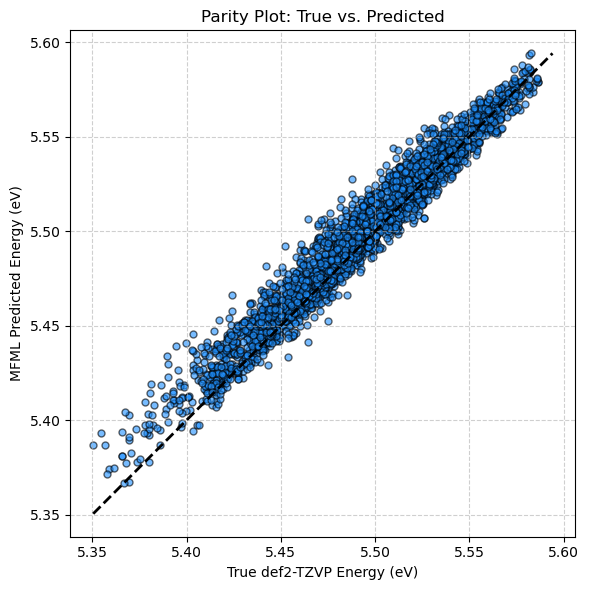

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test_true, preds, alpha=0.6, color="dodgerblue", edgecolor="k", s=25)

# the 45 degree diagonal indicates the ideal of everything matches perfectly
min_val = min(np.min(y_test_true), np.min(preds))
max_val = max(np.max(y_test_true), np.max(preds))
plt.plot([min_val, max_val], [min_val, max_val], "k--", lw=2)

plt.xlabel("True def2-TZVP Energy (eV)")
plt.ylabel("MFML Predicted Energy (eV)")
plt.title("Parity Plot: True vs. Predicted")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()